In [378]:
# Predict Hourly Rate using Linear Regression Model:
# 1. Education (Years)
# 2. Professional Training (Yes=1, No=0)

# =========================
# STEP 1: Import Libraries
# =========================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


In [379]:
# =========================
# STEP 2: Create Dataset
# =========================
data = pd.read_csv('/content/Salary_payment.csv')

df = pd.DataFrame(data)

print("Full Dataset:")
print(df)

Full Dataset:
     Education  Training  HourlyRate
0           16         1          95
1           15         0          68
2           12         1          74
3           18         1         128
4           16         0         103
..         ...       ...         ...
96          18         1         130
97          19         0         111
98          20         1         137
99          21         0         123
100         22         1         149

[101 rows x 3 columns]


In [380]:
# =========================
# STEP 3: Define Features and Target
# =========================

# X = input variables
X = df[["Education", "Training"]]

# y = output variable
y = df["HourlyRate"]

In [381]:
# =========================
# STEP 4: Split into Train and Test Data
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25      # 25% test data

)

In [382]:
# =========================
# SEE TRAIN AND TEST DATA
# =========================

print("\nX_train:")
print(X_train)

print("\nX_test:")
print(X_test)

print("\ny_train:")
print(y_train)

print("\ny_test:")
print(y_test)


X_train:
    Education  Training
23         20         0
83         18         0
75         10         0
38         20         1
73         21         0
..        ...       ...
48         12         0
42         21         1
68         16         0
33         13         0
52         21         0

[75 rows x 2 columns]

X_test:
    Education  Training
16         18         0
47         13         1
41         22         1
49         18         0
94         16         1
77         12         0
61         20         0
62         21         1
34         12         1
71         19         0
76         11         0
46         14         0
44         16         1
21         16         1
26         11         1
35         16         0
85         20         0
45         15         1
2          12         1
96         18         1
63         22         1
36         18         1
99         21         0
18         12         0
79         14         0
97         19         0

y_train:
23    115
83

In [383]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(75, 2)
(26, 2)
(75,)
(26,)


In [384]:
# =========================
# STEP 5: Train Linear Regression Model
# =========================

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [385]:
# =========================
# STEP 6: Make Predictions
# =========================

y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred)


Predictions:
[103.73266178  82.38728722 148.34621794 103.73266178 104.37359746
  59.76004129 118.39020194 141.01744786  75.05851713 111.06143186
  52.43127121  74.41758145 104.37359746 104.37359746  67.72974705
  89.07512162 118.39020194  97.04482738  75.05851713 119.03113762
 148.34621794 119.03113762 125.71897202  59.76004129  74.41758145
 111.06143186]


In [386]:
print("Actual Values:")
print(y_test.to_numpy())

Actual Values:
[108  79 148 107 107  62 118 142  76 113  57  71 104  99  69 100 117  93
  74 130 150 129 123  61  74 111]


In [387]:
# =========================
# STEP 7: Evaluate Model
# =========================

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Absolute Error:", mae)
print("R2 Score:", r2)


Mean Absolute Error: 3.07073006675943
R2 Score: 0.9740357583415774


In [388]:
# =========================
# STEP 8: Model Equation
# =========================

print("\nIntercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Equation:
# HourlyRate =
# intercept +
# coef1 * Education +
# coef2 * Training



Intercept: -28.18519967884059
Coefficients: [ 7.32877008 15.29847584]


I am using Python’s pickle module to save the trained machine learning model into a .pkl file. This allows the model to be reused later for predictions without training it again every time.

For Visual Studio Code users:
In VS Code, you do not need google.colab or drive.mount().
Just save the file directly to a folder on your computer.

In [375]:
import pickle
from google.colab import drive
drive.mount('/content/drive')
with open ('/content/drive/MyDrive/ML model save files/salary_prediction_model.pkl','wb') as f:
  pickle.dump(model,f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [376]:
# =========================
# STEP 9: Predict NEW DATA
# =========================

# Example:
# Education = 17 years
# Training = Yes (1)

new_data = pd.DataFrame({
    "Education": [18,17,15,14],
    "Training": [1,0,1,0]
})

prediction = model.predict(new_data)

print("\nPrediction for New Data: ")
for i in range(len(new_data)):
    education = new_data.loc[i, 'Education']
    training = "Yes" if new_data.loc[i, 'Training'] == 1 else "No"
    predicted_rate = prediction[i]
    print(f"Education: {education}, Training: {training}, Predicted Hourly Rate: {predicted_rate:.2f}")



Prediction for New Data: 
Education: 18, Training: Yes, Predicted Hourly Rate: 118.68
Education: 17, Training: No, Predicted Hourly Rate: 97.25
Education: 15, Training: Yes, Predicted Hourly Rate: 96.64
Education: 14, Training: No, Predicted Hourly Rate: 75.21


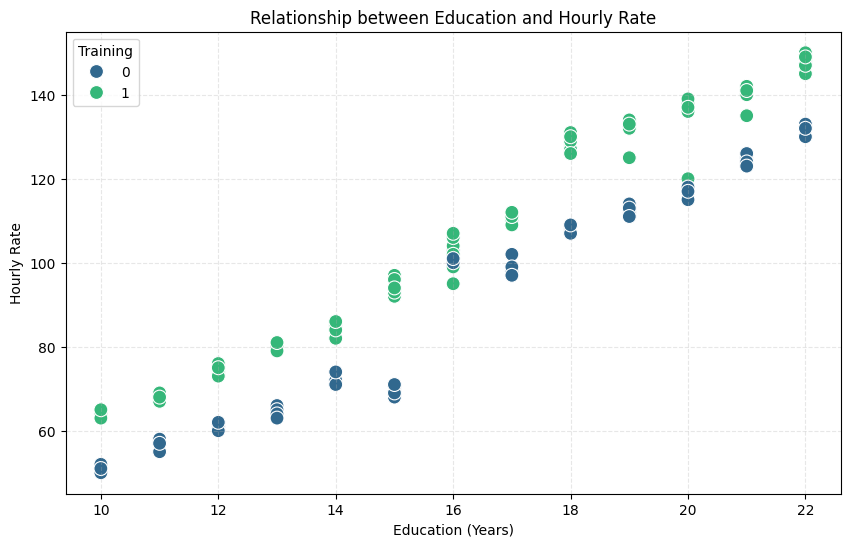

In [389]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Education', y='HourlyRate', data=df, hue='Training', palette='viridis', s=100)
plt.title('Relationship between Education and Hourly Rate')
plt.xlabel('Education (Years)')
plt.ylabel('Hourly Rate')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### How to Load the Model

To use the saved model, execute the following code (either in this notebook or a new one) after mounting your Google Drive:

In [390]:
with open ("/content/drive/MyDrive/ML model save files/salary_prediction_model.pkl",'rb') as f:
  model = pickle.load(f)
new_data = pd.DataFrame({'Education': [12,13,12,13,15],
                         'Training':[1,0,0,1,0]})
prediction = model.predict(new_data)

print(prediction)

[74.58932641 67.85607233 60.50708697 81.93831177 82.55404306]


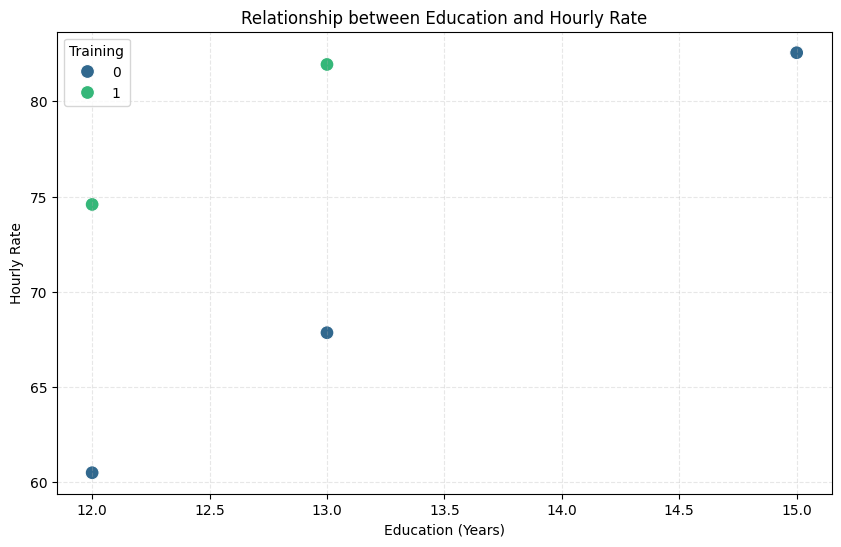

In [391]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the DataFrame 'df' by combining new_data and prediction
dataframe = new_data.copy()
dataframe['HourlyRate'] = prediction

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Education', y='HourlyRate', data=dataframe, hue='Training', palette='viridis', s=100)
plt.title('Relationship between Education and Hourly Rate')
plt.xlabel('Education (Years)')
plt.ylabel('Hourly Rate')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Graph Analysis: Education, Training, and Hourly Rate

The scatter plot illustrates the relationship between years of education, training status, and predicted hourly rates. A key observation from the graph is that 15 years of education yields an hourly rate comparable to that achieved with 13 years of education combined with one training course. This suggests that training programs can significantly impact earning potential, potentially bridging the gap for individuals with fewer years of formal education.